In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cleaning

In [3]:
df = pd.read_csv("Advertising Budget and Sales.csv")
df.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.tail()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               200 non-null    int64  
 1   TV Ad Budget ($)         200 non-null    float64
 2   Radio Ad Budget ($)      200 non-null    float64
 3   Newspaper Ad Budget ($)  200 non-null    float64
 4   Sales ($)                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [6]:
df.isnull().sum()

Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

In [7]:
df = df.drop(columns= ['Unnamed: 0'], axis = 1)
df

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [8]:
df.size

800

In [9]:
df.shape

(200, 4)

In [10]:
df.duplicated().sum()

np.int64(0)

# EDA

In [11]:
df

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [12]:
df.describe()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [13]:
df.skew()

TV Ad Budget ($)          -0.069853
Radio Ad Budget ($)        0.094175
Newspaper Ad Budget ($)    0.894720
Sales ($)                  0.407571
dtype: float64

Some Lower values  are there in TV AD Budget so skew() is negative not suspisious.

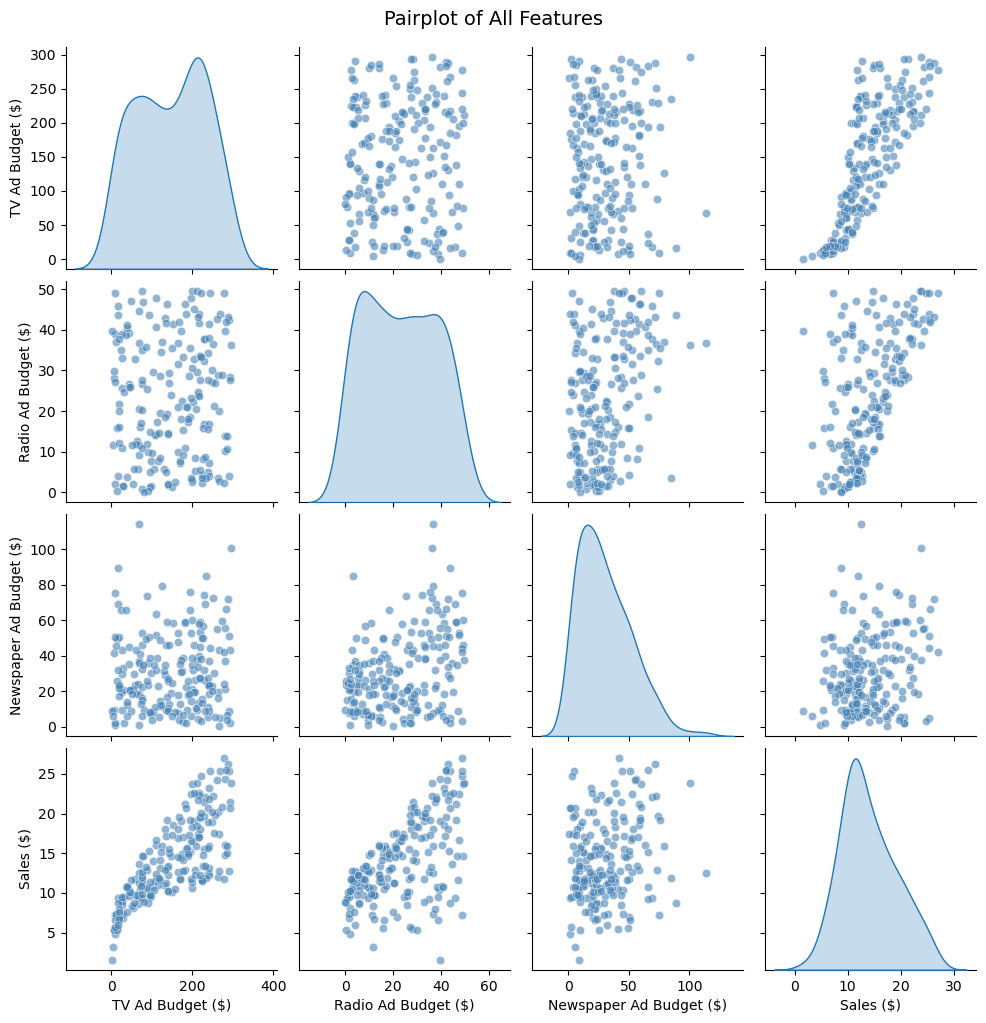

In [14]:
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.6, 'color': 'steelblue'})
plt.suptitle('Pairplot of All Features', y=1.02, fontsize=14)
plt.show()

1. **TV Ad Budget** is the **strongest predictor** of Sales — clear linear trend
2. **Radio** has **moderate influence** — worth including in the model
3. **Newspaper** shows very **weak correlation** — may not add much predictive power
4. No multicollinearity between features — ideal for Linear Regression
5. **Newspaper** is **right-skewed** nearly going to positive — most budgets are small with few large outliers

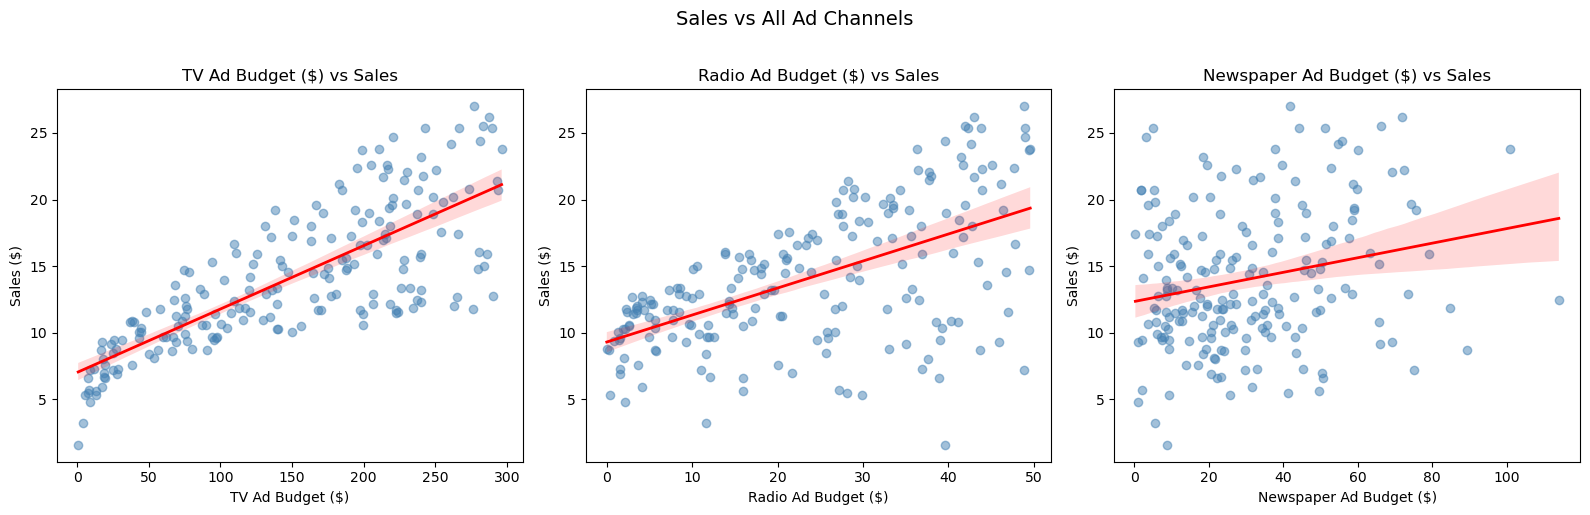

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
channels = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']
for ax, col in zip(axes, channels):
    sns.regplot(x=col, y='Sales ($)', data=df, ax=ax,
                scatter_kws={'alpha': 0.5, 'color': 'steelblue'},
                line_kws={'color': 'red', 'linewidth': 2})
    ax.set_title(f'{col} vs Sales')
plt.suptitle('Sales vs All Ad Channels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Before Jump into ML model it's confirm that **Newpaper ad budget** has a bad realtionship with **sales** in future for better result I will try to train my model without Newspaper Ad budget column

In [16]:
np.corrcoef(df)

array([[ 1.        ,  0.5429125 , -0.25741671, ...,  0.97209458,
         0.99763425,  0.97550501],
       [ 0.5429125 ,  1.        ,  0.62929429, ...,  0.36360401,
         0.50068397,  0.37276727],
       [-0.25741671,  0.62929429,  1.        , ..., -0.46924202,
        -0.3164027 , -0.45799056],
       ...,
       [ 0.97209458,  0.36360401, -0.46924202, ...,  1.        ,
         0.98561106,  0.99986547],
       [ 0.99763425,  0.50068397, -0.3164027 , ...,  0.98561106,
         1.        ,  0.9879358 ],
       [ 0.97550501,  0.37276727, -0.45799056, ...,  0.99986547,
         0.9879358 ,  1.        ]], shape=(200, 200))

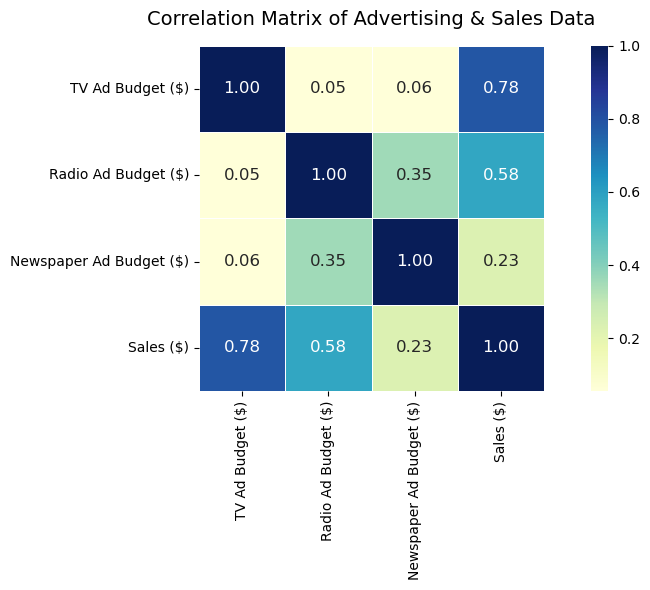

In [ ]:
plt.figure(figsize=(10, 6))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,           
    fmt='.2f',            
    cmap='YlGnBu',      
    linewidths=0.5,
    linecolor='white',
    square=True,
    annot_kws={'size': 12}
)

plt.title('Correlation Matrix of Advertising & Sales Data', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

TV Ad Budget has the strongest correlation with Sales (≈0.78) and with Radio (≈0.58). Newspaper shows a weak correlation (≈0.23). This shows  how it is appropiate for Linear Regression model. Sales has strong rltnship between TV Ad Budget, Radio Ad Budget, so model can easily find its dependencies for prediction.

# Featuring & Spliting 

In [18]:
from sklearn.model_selection import train_test_split
#Separte Features ans Targeted column
features = ['TV Ad Budget ($)',	'Radio Ad Budget ($)',	'Newspaper Ad Budget ($)']

X = df[features]
y = df['Sales ($)']

print(X)
print(y)

     TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)
0               230.1                 37.8                     69.2
1                44.5                 39.3                     45.1
2                17.2                 45.9                     69.3
3               151.5                 41.3                     58.5
4               180.8                 10.8                     58.4
..                ...                  ...                      ...
195              38.2                  3.7                     13.8
196              94.2                  4.9                      8.1
197             177.0                  9.3                      6.4
198             283.6                 42.0                     66.2
199             232.1                  8.6                      8.7

[200 rows x 3 columns]
0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales ($), Length: 200

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Model

## Linear Regression Base Model 

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train,y_train)

y_pred_lin_reg = model_lin_reg.predict(X_test)
print("Model Training is completed.")

compare = pd.DataFrame({
    'Actual Sales ($)': y_test.values.flatten(),      # flatten to 1D
    'Predicted Sales ($)': y_pred_lin_reg.flatten()
})

print(compare.to_string(index=False))

print("Model Coeficient(slope) is =",model_lin_reg.coef_) 
print('Model intercept is =',model_lin_reg.intercept_) 

Model Training is completed.
 Actual Sales ($)  Predicted Sales ($)
             16.9            16.408024
             22.4            20.889882
             21.4            21.553843
              7.3            10.608503
             24.7            22.112373
             12.6            13.105592
             22.3            21.057192
              8.4             7.461010
             11.5            13.606346
             14.9            15.155070
              9.5             9.048320
              8.7             6.653283
             11.9            14.345545
              5.3             8.903493
             10.3             9.689590
             11.7            12.164944
              5.5             8.736284
             16.6            16.265073
             11.3            10.277596
             18.9            18.831091
             19.7            19.560367
             12.5            13.251035
             10.9            12.336207
             22.2            21.306

### Error Matrics for Linear Regression

In [21]:
MAE  = mean_absolute_error(y_test, y_pred_lin_reg)
MSE  = mean_squared_error(y_test, y_pred_lin_reg)
RMSE = root_mean_squared_error(y_test, y_pred_lin_reg)
R2   = r2_score(y_test,y_pred_lin_reg)
print(f"{MAE:.4f} is the MAE score\n{MSE:.4f} is the MSE score\n{RMSE:.4f} is the RMSE score\n{R2:.4f} is the R2 score")

1.4608 is the MAE score
3.1741 is the MSE score
1.7816 is the RMSE score
0.8994 is the R2 score


### Error Visuals

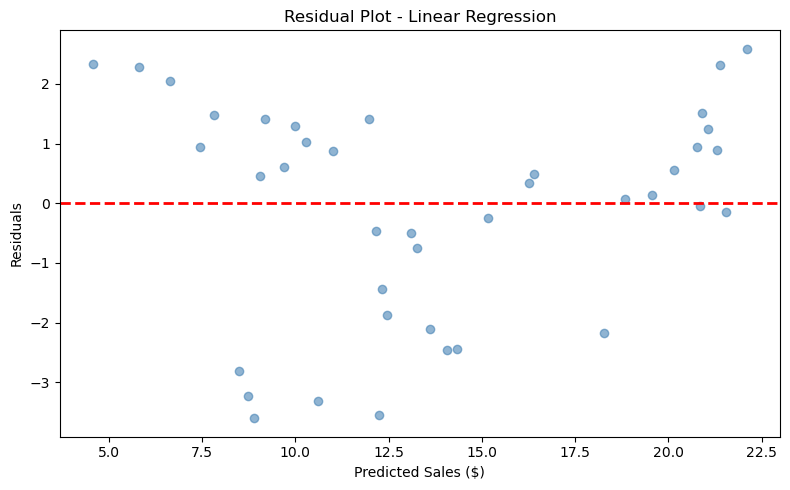

In [36]:
# Residual Plot
residuals = y_test.values.flatten() - y_pred_lin_reg.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_lin_reg, residuals, alpha=0.6, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales ($)')
plt.ylabel('Residuals')
plt.title('Residual Plot - Linear Regression')
plt.tight_layout()
plt.savefig("Base_model_linear_reg.png")
plt.show()

The residual plot shows randomly distributed errors around the zero line, confirming that the Linear Regression model has no systematic bias. However, a slightly wider spread of residuals is observed at lower predicted values (5–12). Overall, the model assumptions are satisfied.

## Random Forest Regressor

In [23]:
from sklearn.ensemble import RandomForestRegressor

model_RF_reg = RandomForestRegressor(n_estimators=100, random_state=42)
model_RF_reg.fit(X_train,y_train)

y_pred_RF_reg = model_RF_reg.predict(X_test)
print("Model Training is completed.")

compare_RF_reg = pd.DataFrame({
    'Actual Sales ($)': y_test.values.flatten(),      # flatten to 1D
    'Predicted Sales ($)': y_pred_RF_reg.flatten()
})

print(compare_RF_reg.to_string(index=False))


Model Training is completed.
 Actual Sales ($)  Predicted Sales ($)
             16.9               17.698
             22.4               21.804
             21.4               20.628
              7.3                6.793
             24.7               22.927
             12.6               13.379
             22.3               22.376
              8.4                9.688
             11.5               11.826
             14.9               15.540
              9.5                7.344
              8.7                9.059
             11.9               12.109
              5.3                4.826
             10.3               10.522
             11.7               12.690
              5.5                6.490
             16.6               16.440
             11.3               11.368
             18.9               19.732
             19.7               20.181
             12.5               12.884
             10.9               10.330
             22.2               22.

### Error Matrics for Random Forest Regression

In [24]:
MAE_RF_reg  = mean_absolute_error(y_test, y_pred_RF_reg)
MSE_RF_reg  = mean_squared_error(y_test, y_pred_RF_reg)
RMSE_RF_reg = root_mean_squared_error(y_test, y_pred_RF_reg)
R2_RF_reg   = r2_score(y_test,y_pred_RF_reg)
print(f"{MAE_RF_reg:.4f} is the MAE score\n{MSE_RF_reg:.4f} is the MSE score\n{RMSE_RF_reg:.4f} is the RMSE score\n{R2_RF_reg:.4f} is the R2 score")

0.6201 is the MAE score
0.5907 is the MSE score
0.7686 is the RMSE score
0.9813 is the R2 score


**RMSE(Root Mean Squared error)** means - On average, model prediction is only off by $0.77 from actual sales. 
**R2 score** means - model explains **98.13%** of the variation in Sales. Only 1.87% is unexplained.

### Error Visuals for RF

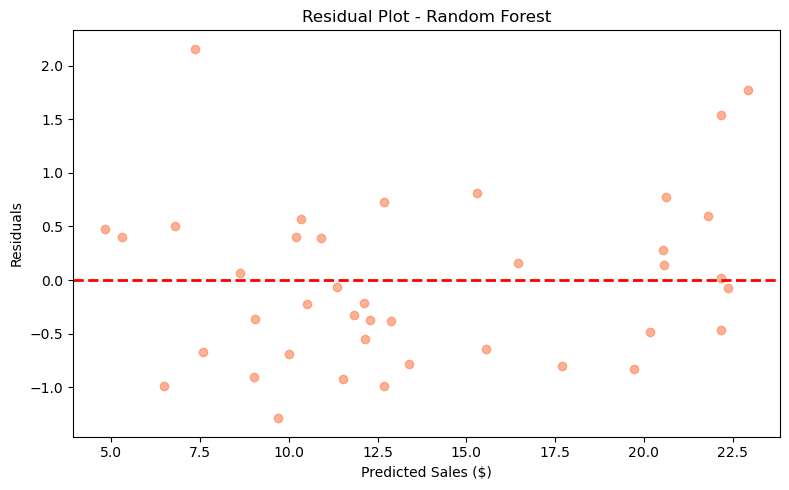

In [37]:
# Residual Plot - Random Forest
residuals_RF = y_test.values.flatten() - y_pred_RF_reg.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_RF_reg, residuals_RF, alpha=0.6, color='coral')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales ($)')
plt.ylabel('Residuals')
plt.title('Residual Plot - Random Forest')
plt.tight_layout()
plt.savefig("RandomForest_reg.png")
plt.show()

In Linear Regression, some dots went as far as -3.5 from the zero line. In Random Forest reg, the worst is only -1.3 — much closer to zero. Random Forest is more accurate.Linear Regression had wide spread especially at low sales predictions. Random Forest's dots are tighter around the red line throughout.

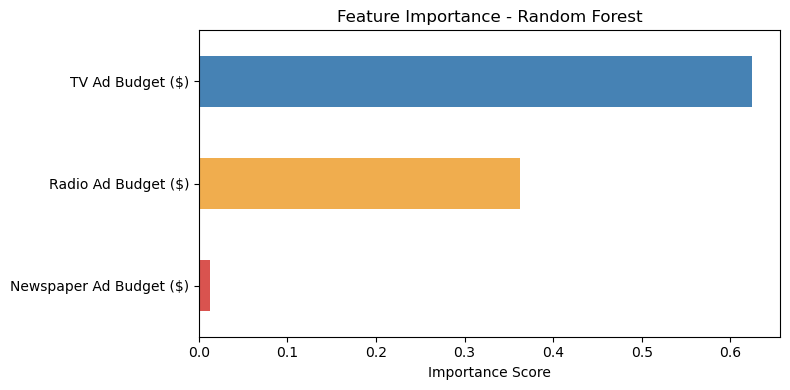

In [38]:
# Feature Importance - answers "which channel impacts sales most?"
feature_importance = pd.Series(
    model_RF_reg.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
feature_importance.plot(kind='barh', color=['#d9534f','#f0ad4e','steelblue'])
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("Features_importance_of_rf_reg.png")
plt.show()

As we saw at previous that TV AD Budget has a good relation with sales and now we can see it after model trainnig that the most revenue is comming from TV Ad BUdget sales.

## Polynomial Regression

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly = PolynomialFeatures(degree=2, include_bias=False)

model_poly = Pipeline([
    ('polynomial_feature',poly),
    ('linear_reg', LinearRegression())
    ])

model_poly.fit(X_train,y_train)

y_pred_poly_reg = model_poly.predict(X_test)


compare_poly_reg = pd.DataFrame({
    'Actual Sales ($)': y_test.values.flatten(),      # flatten to 1D
    'Predicted Sales ($)': y_pred_poly_reg.flatten()
})

print(compare_poly_reg.to_string(index=False))

 Actual Sales ($)  Predicted Sales ($)
             16.9            17.254436
             22.4            22.719332
             21.4            20.427994
              7.3             7.542709
             24.7            24.371030
             12.6            12.559272
             22.3            22.807850
              8.4             8.343714
             11.5            12.058602
             14.9            15.690246
              9.5             7.891664
              8.7             8.270827
             11.9            11.860560
              5.3             6.165911
             10.3            10.576644
             11.7            12.362895
              5.5             6.743910
             16.6            16.650821
             11.3            10.686617
             18.9            19.038882
             19.7            20.152239
             12.5            13.113781
             10.9             9.562739
             22.2            22.106752
              9.3        

In [28]:
MAE_poly_reg  = mean_absolute_error(y_test, y_pred_poly_reg)
MSE_poly_reg  = mean_squared_error(y_test, y_pred_poly_reg)
RMSE_poly_reg = root_mean_squared_error(y_test, y_pred_poly_reg)
R2_poly_reg   = r2_score(y_test,y_pred_poly_reg)
print(f"{MAE_poly_reg:.4f} is the MAE score\n{MSE_poly_reg:.4f} is the MSE score\n{RMSE_poly_reg:.4f} is the RMSE score\n{R2_poly_reg:.4f} is the R2 score")

0.5262 is the MAE score
0.4129 is the MSE score
0.6426 is the RMSE score
0.9869 is the R2 score


### Visuals

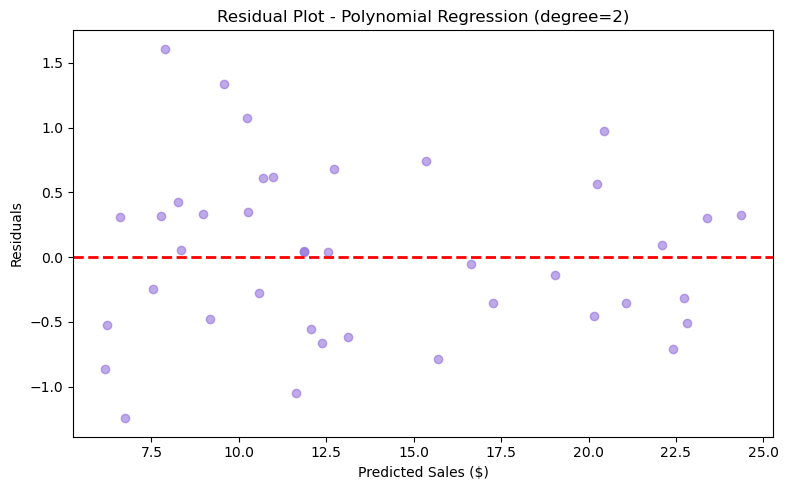

In [39]:
residuals_poly = y_test.values.flatten() - y_pred_poly_reg.flatten()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_poly_reg, residuals_poly, alpha=0.6, color='mediumpurple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales ($)')
plt.ylabel('Residuals')
plt.title('Residual Plot - Polynomial Regression (degree=2)')
plt.tight_layout()
plt.savefig("Polynomial_reg.png")
plt.show()

# Final Results

In [30]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Polynomial Regression'],
    'MAE':   [MAE, MAE_RF_reg, MAE_poly_reg],
    'RMSE':  [RMSE, RMSE_RF_reg, RMSE_poly_reg],
    'R²':    [R2, R2_RF_reg, R2_poly_reg]
})
print(results.to_string(index=False))

                Model      MAE     RMSE       R²
    Linear Regression 1.460757 1.781600 0.899438
        Random Forest 0.620100 0.768591 0.981284
Polynomial Regression 0.526179 0.642581 0.986918


The **Polynomial Regression model**(degree=2) achieved the **highest R² score of 0.9869**, explaining **98.69% of variance** in Sales with an RMSE of only 0.64. The **Rnadom Forest Regression model** achieved the **0.9813 R² score** , explaining **98.13% of variance** in Sales with an RMSE of only 0.77, making **Polynomial Regression** the ****best model**** for this advertising dataset, but my personal opinion is We should go with Random Forest, polynomial regression can be overfit with unseen data.

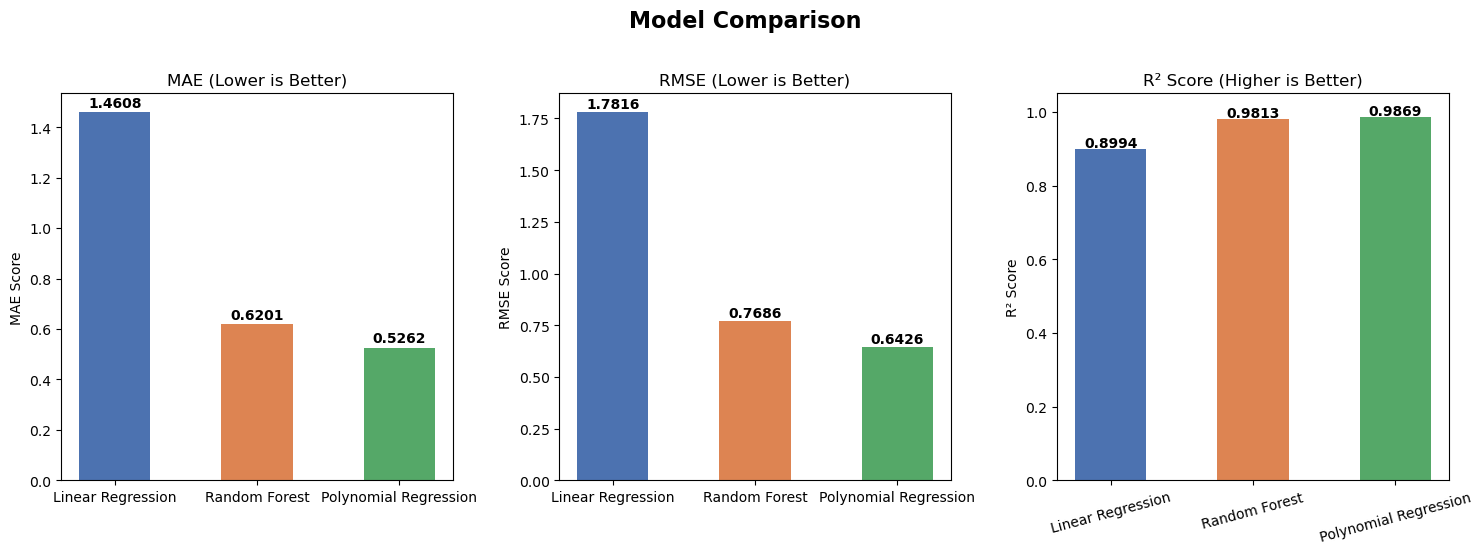

In [40]:
# Model Comparison
models     = ['Linear Regression', 'Random Forest', 'Polynomial Regression']
mae_scores = [MAE,       MAE_RF_reg,  MAE_poly_reg]
rmse_scores= [RMSE,      RMSE_RF_reg, RMSE_poly_reg]
r2_scores  = [R2,        R2_RF_reg,   R2_poly_reg]
colors     = ['#4C72B0', '#DD8452',   '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison', fontsize=16, fontweight='bold', y=1.02)



#MAE 
axes[0].bar(models, mae_scores, color=colors, width=0.5)
axes[0].set_title('MAE (Lower is Better)', fontsize=12)
axes[0].set_ylabel('MAE Score')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE
axes[1].bar(models, rmse_scores, color=colors, width=0.5)
axes[1].set_title('RMSE (Lower is Better)', fontsize=12)
axes[1].set_ylabel('RMSE Score')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# R² 
axes[2].bar(models, r2_scores, color=colors, width=0.5)
axes[2].set_title('R² Score (Higher is Better)', fontsize=12)
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1.05)
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

    
plt.tight_layout()
plt.xticks(rotation=15)
plt.savefig("Model_Comparison.png")
plt.show()

Polynomial Regression outperforms both models across all metrics — lowest MAE, lowest RMSE, and highest R² of 0.9813 — making it the best model for predicting sales from advertising budgets.